In [19]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pandas as pd
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy


(736, 736, 3)


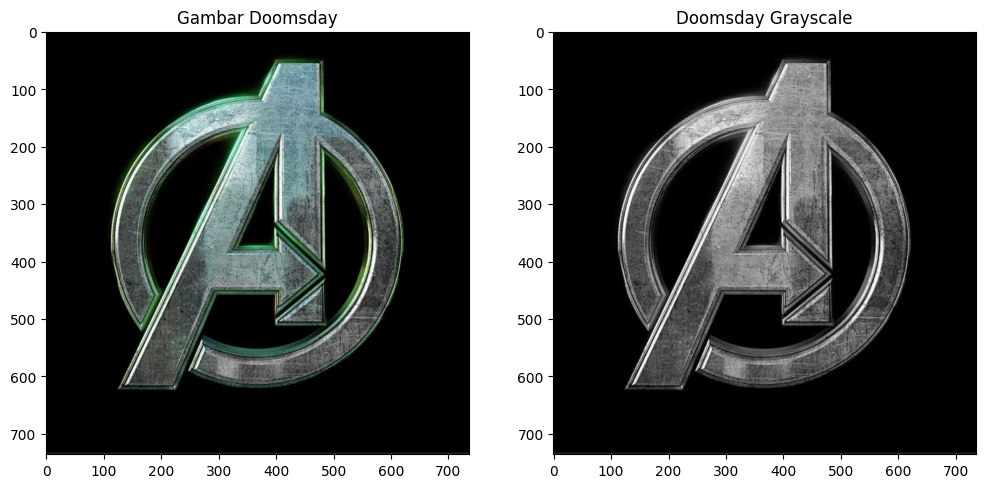

In [20]:
img = cv.imread('doomsday.jpg')
DoomsdayRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB)
Doomsdaygray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(12,8))

plt.subplot(1,2,1)
plt.title('Gambar Doomsday')
plt.imshow(DoomsdayRGB, cmap='gray')
print(DoomsdayRGB.shape)

plt.subplot(1,2,2)
plt.title('Doomsday Grayscale')
plt.imshow(Doomsdaygray, cmap='gray')


In [22]:
nilai = 1/1.4142135623730950488016887242097
LPF = np.array([1/np.sqrt(2), 1/np.sqrt(2)]) 

HPF = np.array([
    -1/np.sqrt(2),
     1/np.sqrt(2)
])

LPF = np.array([
    1/np.sqrt(2), 1/np.sqrt(2)]) #low-pass filter

In [24]:
def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((0, 0), (pad_width, pad_width)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))

    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i][j + x] * kernel[x]
    return conv

def convo_h(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2

    padd = np.pad(
        image,
        ((0,0),(pad_width,pad_width)),
        mode='constant'
    )

    conv = np.zeros(image.shape)

    for i in range(conv.shape[0]):
        for j in range(conv.shape[1]):
            for x in range(ukuran_kernel):
                conv[i,j] += (
                    padd[i,j+x]
                    * kernel[ukuran_kernel-1-x]
                )

    return conv

def convo_v(image, kernel):
    ukuran_kernel = len(kernel)
    pad_width = ukuran_kernel // 2
    padd = np.pad(image, ((pad_width, pad_width), (0, 0)), mode='constant')
    conv = np.zeros((image.shape[0], image.shape[1]))
    for i in range(len(conv)):
        for j in range(len(conv[i])):
            for x in range(len(kernel)):
                conv[i][j] += padd[i + x][j] * kernel[x]
    return conv

def downsampling_h(image):
    downsampled = np.zeros((image.shape[0], image.shape[1] // 2))
    for i in range(len(downsampled)):
        indeks = 0
        for j in range(len(downsampled[i])):
            downsampled[i][j] = image[i][indeks]
            indeks += 2
    return downsampled

def downsampling_v(image):
    baris = int(image.shape[0] / 2)
    kolom = int(image.shape[1])
    downsampled = np.zeros((baris, kolom))
    indeks = 0
    for i in range(baris):
        for j in range(kolom):
            downsampled[i][j] = image[indeks][j]
        indeks += 2
    return downsampled

def normalisasi(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros(image.shape)
    return (image - min_val) / (max_val - min_val) * 255



In [25]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)): 
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

In [ ]:
def graycomatrix(image, distances, angles, levels=256, symmetric=True, normed=True):
    angle = angles[0]

    if angle == 0:
        dr, dc = 0, 1
    elif angle == np.pi / 4: # 45 derajat
        dr, dc = -1, 1
    elif angle == np.pi / 2: # 90 derajat
        dr, dc = -1, 0
    elif angle == 3 * np.pi / 4: # 135 derajat
        dr, dc = -1, -1

    glcm_matrix = np.zeros((levels, levels))
    h, w = image.shape

    for i in range(h):
        for j in range(w):
            row_tetangga = i + dr
            col_tetangga = j + dc

            if 0 <= row_tetangga < h and 0 <= col_tetangga < w:
                ref_pixel = int(image[i][j])
                neighbor_pixel = int(image[row_tetangga][col_tetangga])
                glcm_matrix[ref_pixel][neighbor_pixel] += 1

    if symmetric:
        glcm_matrix = glcm_matrix + glcm_matrix.T

    if normed:
        total = np.sum(glcm_matrix)
        if total > 0:
            glcm_matrix = glcm_matrix / total

    return np.reshape(glcm_matrix, (levels, levels, 1, 1))


def graycoprops(matriks, prop):
    glcm = matriks[:, :, 0, 0]
    levels = glcm.shape[0]

    i_indices, j_indices = np.ogrid[:levels, :levels]

    if prop == 'contrast':
        weights = (i_indices - j_indices) ** 2
        hasil = np.sum(glcm * weights)

    elif prop == 'dissimilarity':
        weights = np.abs(i_indices - j_indices)
        hasil = np.sum(glcm * weights)

    elif prop == 'homogeneity':
        weights = 1.0 / (1.0 + (i_indices - j_indices) ** 2)
        hasil = np.sum(glcm * weights)

    elif prop == 'ASM':
        hasil = np.sum(glcm ** 2)

    elif prop == 'energy':
        hasil = np.sqrt(np.sum(glcm ** 2))

    elif prop == 'correlation':
        mean_i = np.sum(i_indices * glcm)
        mean_j = np.sum(j_indices * glcm)

        std_i = np.sqrt(np.sum(((i_indices - mean_i) ** 2) * glcm))
        std_j = np.sqrt(np.sum(((j_indices - mean_j) ** 2) * glcm))

        if std_i == 0 or std_j == 0:
            hasil = 0
        else:
            titik_tengah = (i_indices - mean_i) * (j_indices - mean_j)
            hasil = np.sum(glcm * titik_tengah) / (std_i * std_j)

    return np.array([[hasil]])

def entropy(elemen_matriks):
    p = elemen_matriks[elemen_matriks > 0]

    if len(p) == 0:
        return 0.0

    return -np.sum(p * np.log2(p))

In [26]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [15]:
def upsampling_v(image):
    upsampled = np.zeros((image.shape[0] * 2, image.shape[1]))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i * 2][j] = image[i][j]
    return upsampled

def upsampling_h(image):
    upsampled = np.zeros((image.shape[0], image.shape[1] * 2))
    for i in range(len(image)):
        for j in range(len(image[i])):
            upsampled[i][j * 2] = image[i][j]
    return upsampled

def rekonstruksi(LL, LH, HL, HH, LPF, HPF):
    upsampling = upsampling_v(LL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(LH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiL2 = convo_h(upsampling, LPF)

    upsampling = upsampling_v(HL)
    konvolusiL = convo_v(upsampling, LPF)

    upsampling = upsampling_v(HH)
    konvolusiH = convo_v(upsampling, HPF)

    upsampling = upsampling_h(konvolusiL + konvolusiH)
    konvolusiH2 = convo_h(upsampling, HPF)

    hasil = konvolusiL2 + konvolusiH2
    return hasil

# hasil = rekonstruksi(approximation, horizontal, vertikal, diagonal, LPF, HPF)

In [27]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [28]:
def resized(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

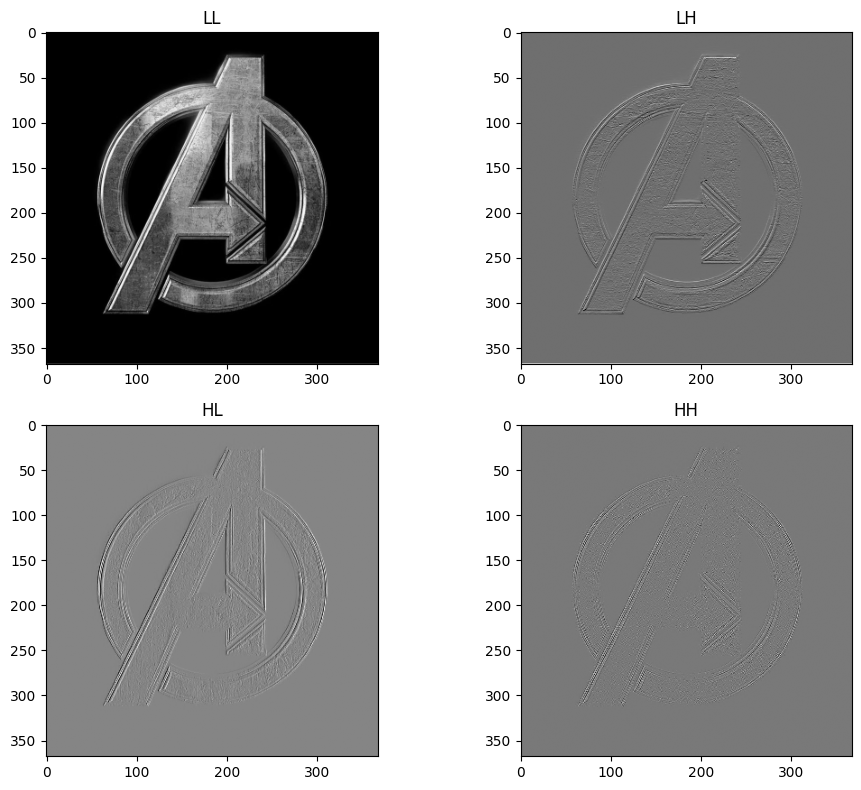

In [30]:
convLL_1 = convo_h(Doomsdaygray, LPF)
downLL_1 = downsampling_h(convLL_1)
convLL_2 = convo_v(downLL_1, LPF)
LL = downsampling_v(convLL_2)
LLNormalisasi = normalisasi(LL)

convLH_1 = convo_h(Doomsdaygray, LPF)
downLH_1 = downsampling_h(convLH_1)
convLH_2 = convo_v(downLH_1, HPF)
LH = downsampling_v(convLH_2)
LHNormalisasi = normalisasi(LH)

convHL_1 = convo_h(Doomsdaygray, HPF)
downHL_1 = downsampling_h(convHL_1)
convHL_2 = convo_v(downHL_1, LPF)
HL = downsampling_v(convHL_2)
HLNormalisasi = normalisasi(HL)

convHH_1 = convo_h(Doomsdaygray, HPF)
downHH_1 = downsampling_h(convHH_1)
convHH_2 = convo_v(downHH_1, HPF)
HH = downsampling_v(convHH_2)
HHNormalisasi = normalisasi(HH).astype(np.uint8)

plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(LLNormalisasi, cmap='gray')
plt.title('LL')

plt.subplot(2,2,2)
plt.imshow(LHNormalisasi, cmap='gray')
plt.title('LH')

plt.subplot(2,2,3)
plt.imshow(HLNormalisasi, cmap='gray')
plt.title('HL')

plt.subplot(2,2,4)
plt.imshow(HHNormalisasi, cmap='gray')
plt.title('HH')

plt.tight_layout()
plt.show()

In [35]:
def Thresholding(img, batas):
    """
    Thresholding — ubah grayscale jadi biner (hitam putih).
    piksel > batas → 255 (putih)
    piksel <= batas → 0 (hitam)
    Contoh: hasil = Thresholding(gray, 127)
    """
    baris, kolom = img.shape
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(baris):
        for j in range(kolom):
            if img[i,j] >= batas:
                canvas[i,j] = 255
            elif img[i,j] <= batas:
                canvas[i,j] = 0
    return canvas

def Resize(image, new_width, new_height):
    """
    Resize — ubah ukuran citra.
    Contoh: hasil = Resize(citra, 256, 256)
    """
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

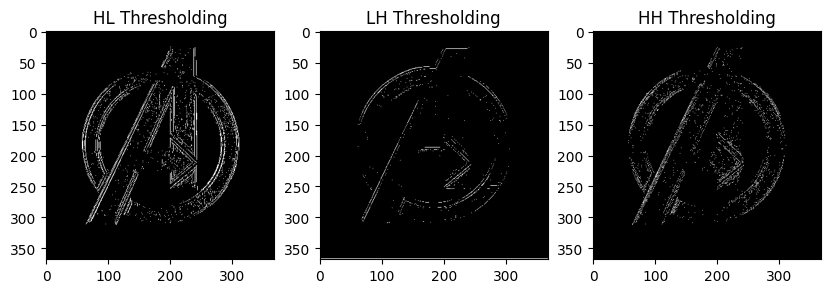

In [36]:
HLRe = cv.resize(HLNormalisasi, (256, 256))
LHRe = cv.resize(LHNormalisasi, (256, 256))
HHRe = cv.resize(HHNormalisasi, (256, 256))

ThresholdHL150 = Thresholding(HLNormalisasi, 150)
ThresholdLH165 = Thresholding(LHNormalisasi, 150)
ThresholdHH150 = Thresholding(HHNormalisasi, 150)

plt.figure(figsize=(10, 5))

plt.subplot(1,3,1)
plt.title('HL Thresholding')
plt.imshow(ThresholdHL150, cmap='gray')

plt.subplot(1,3,2)
plt.title('LH Thresholding')
plt.imshow(ThresholdLH165, cmap='gray')

plt.subplot(1,3,3)
plt.title('HH Thresholding')
plt.imshow(ThresholdHH150, cmap='gray')
plt.show()


In [34]:
def Dilasi(image, kernel):
    """
    Dilasi — perbesar area objek pada citra biner.
    Piksel putih (255) akan meluas sesuai bentuk kernel.
    Contoh: hasil = Dilasi(biner, kernel_cross)
    """
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))

    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i+k-center, j+l-center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0

    return hasil


def Erosi(image, kernel):
    """
    Erosi — kurangi/tipiskan area objek pada citra biner.
    Piksel putih hanya dipertahankan kalau semua tetangganya sesuai kernel.
    Contoh: hasil = Erosi(biner, kernel_cross)
    """
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i+k-center, j+l-center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255

    return hasil

def closing(image, kernel):
    """
    Closing = Dilasi → Erosi
    Menutup lubang kecil di dalam objek.
    Contoh: hasil = closing(biner, kernel_cross)
    """
    return Erosi(Dilasi(image, kernel), kernel)


In [37]:
kernel5 = np.array ([[0, 0, 1, 0, 0],
                     [0, 1, 1, 0, 0],
                     [1, 1, 1, 0, 1],
                     [0, 1, 1, 0, 0],
                     [0, 0, 1, 0, 0]])

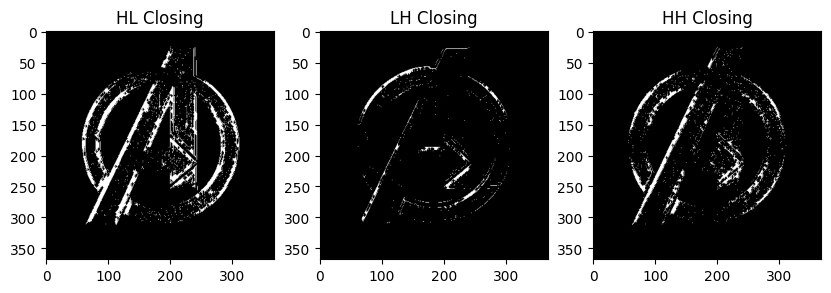

In [39]:
closingHL   = closing(ThresholdHL150, kernel5)
closingLH   = closing(ThresholdLH165, kernel5)
closingHH   = closing(ThresholdHH150, kernel5)

plt.figure(figsize=(10, 5))

plt.subplot(1,3,1)
plt.title('HL Closing')
plt.imshow(closingHL, cmap='gray')

plt.subplot(1,3,2)
plt.title('LH Closing')
plt.imshow(closingLH, cmap='gray')

plt.subplot(1,3,3)
plt.title('HH Closing')
plt.imshow(closingHH, cmap='gray')

plt.show()


# Analisis Hasil Closing pada Subband HL, LH, dan HH

Pada tahap ini dilakukan operasi morfologi **closing** (dilasi lalu erosi) pada hasil thresholding subband HL, LH, dan HH. Tujuannya adalah untuk menutup celah kecil pada objek serta menyambungkan bagian-bagian tepi yang sebelumnya terputus.

Pada **HL Closing**, bentuk logo terlihat paling jelas karena subband HL menyimpan banyak informasi tepi vertikal. Setelah closing, garis-garis objek menjadi lebih tebal dan lebih menyatu sehingga bentuk keseluruhan logo lebih mudah dikenali.

Pada **LH Closing**, objek masih terlihat lebih tipis dan tidak sejelas HL. Hal ini menunjukkan bahwa informasi detail horizontal yang tersimpan pada subband LH relatif lebih sedikit. Meskipun begitu, beberapa bagian yang sebelumnya terputus berhasil tersambung setelah proses closing.

Pada **HH Closing**, detail diagonal tampak lebih menonjol. Garis-garis diagonal pada logo menjadi lebih kontinu dan beberapa lubang kecil pada objek berhasil ditutup, sehingga bentuk simbol terlihat lebih utuh.

Secara keseluruhan, operasi closing berhasil mengurangi celah kecil dan memperbaiki kontinuitas objek pada ketiga subband. Hasil terbaik terlihat pada **HL** dan **HH** karena keduanya menyimpan informasi tepi yang lebih dominan dibandingkan subband **LH**.

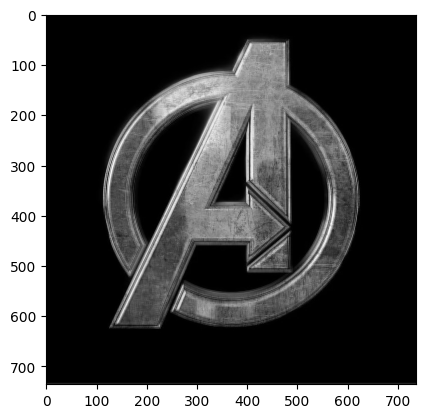

In [40]:
hasilrekonstruksi = rekonstruksi(LL, LH, HL, HH, LPF, HPF)
hasilrekonstruksi = normalisasi(hasilrekonstruksi)
plt.imshow(hasilrekonstruksi, cmap='gray')

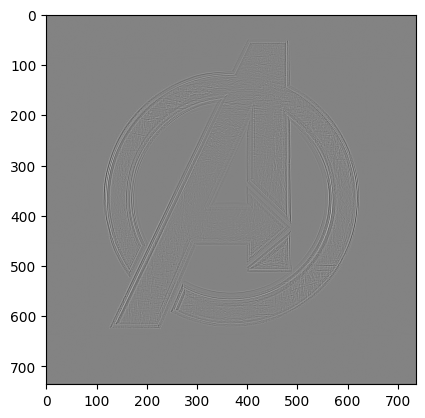

In [41]:
LL0 = np.zeros_like(LLNormalisasi)
hasilLL0 = rekonstruksi(LL0, LH, HL, HH, LPF, HPF)
hasilLL0 = normalisasi(hasilLL0)
plt.imshow(hasilLL0, cmap='gray')

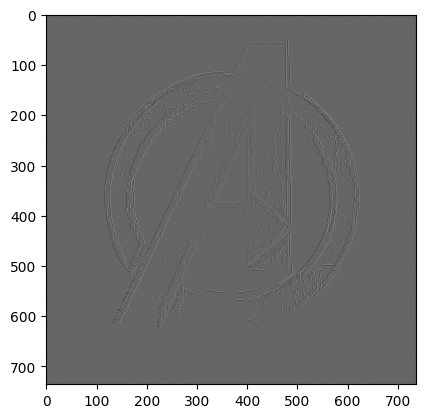

In [45]:
rekonstruksiClosing = rekonstruksi(LL0,closingLH, closingHL, closingHH, LPF, HPF)
rekonstruksiClosing = normalisasi(rekonstruksiClosing)
plt.imshow(rekonstruksiClosing, cmap='gray')

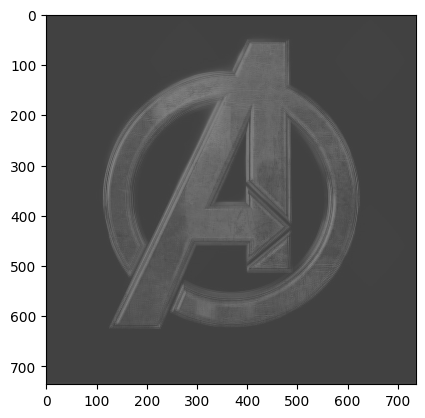

In [43]:
rekonstruksiawal= rekonstruksi(LLNormalisasi,LHNormalisasi, HLNormalisasi, HHNormalisasi, LPF, HPF)
plt.imshow(rekonstruksiawal, cmap='gray')

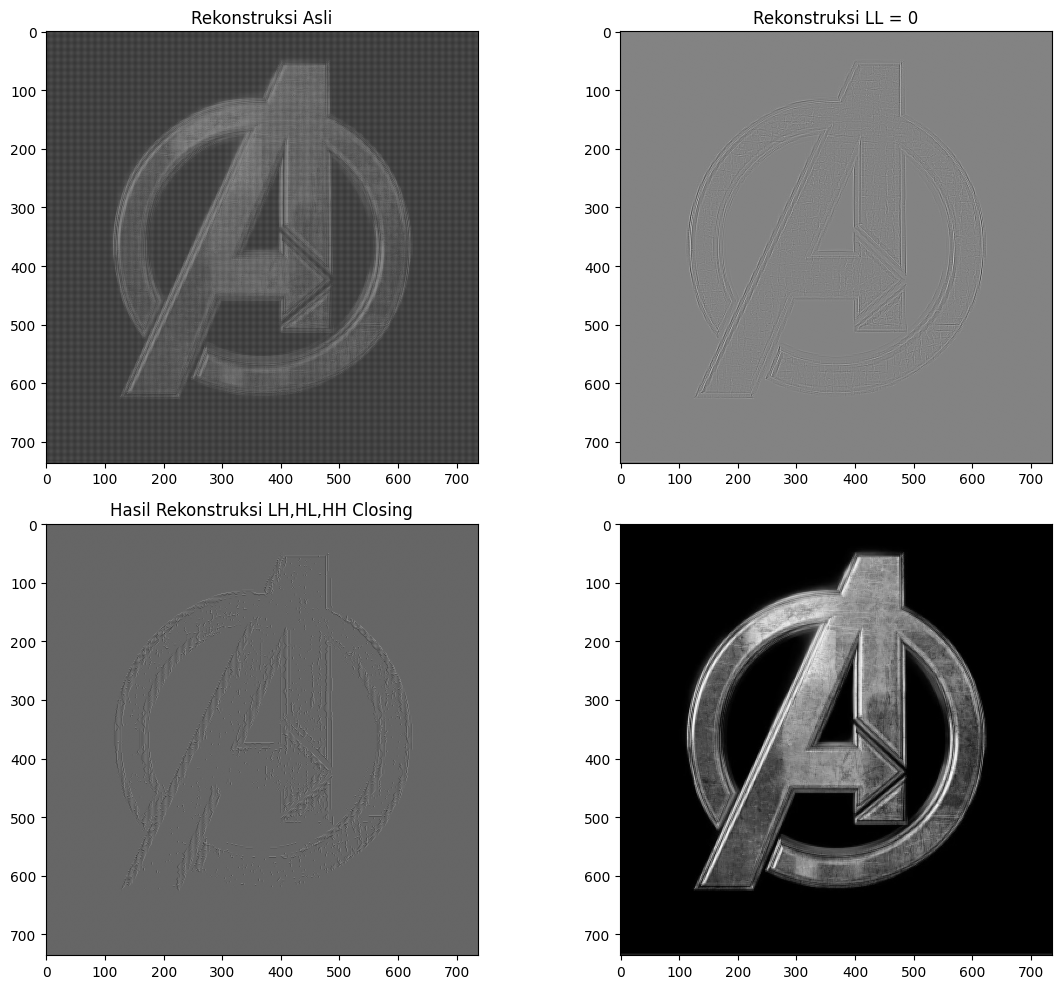

In [44]:
plt.figure(figsize=(12,10))


plt.subplot(2,2,1)
plt.imshow(rekonstruksiawal, cmap='gray')
plt.title('Rekonstruksi Asli')


plt.subplot(2,2,2)
plt.imshow(hasilLL0, cmap='gray')
plt.title('Rekonstruksi LL = 0')


plt.subplot(2,2,3)
plt.imshow(rekonstruksiClosing, cmap='gray')
plt.title('Hasil Rekonstruksi LH,HL,HH Closing')


plt.subplot(2,2,4)
plt.imshow(hasilrekonstruksi, cmap='gray')


plt.tight_layout()
plt.show()

# Analisis Karakteristik Hasil Rekonstruksi Wavelet

**Rekonstruksi Asli** menghasilkan citra yang masih menyerupai objek asli karena menggunakan seluruh subband wavelet (LL, LH, HL, dan HH). Bentuk logo terlihat lengkap meskipun masih terdapat tekstur pada latar belakang.

**Rekonstruksi LL = 0** hanya menampilkan informasi tepi karena komponen LL dihilangkan. Akibatnya citra terlihat seperti sketsa atau emboss dan kehilangan informasi intensitas utama.

**Hasil Rekonstruksi LH, HL, HH Closing** menunjukkan tepi objek yang lebih rapi dan menyambung dibanding sebelumnya. Operasi closing berhasil menutup celah kecil pada kontur sehingga bentuk logo menjadi lebih jelas.

**Hasil Rekonstruksi Lengkap** memberikan hasil terbaik karena menggabungkan informasi bentuk dan detail secara bersamaan. Logo terlihat paling jelas, utuh, dan mudah dikenali.

Dapat disimpulkan bahwa subband **LL menyimpan informasi utama citra**, sedangkan **LH, HL, dan HH menyimpan detail tepi**. Proses **closing** membantu memperbaiki kualitas tepi sebelum dilakukan rekonstruksi.